<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/Week11/DailyChallenge_Introduction_to_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** GenAI & Machine Learning Bootcamp 2025 - Part Time 2025 - WW Deep Learning Introduction to Deep Learning Daily Challenge**

https://octopus.developers.institute/courses/collection/124/course/722/section/1963/chapter/4381#

1. Load and Preprocess the MNIST Dataset

Load the MNIST dataset using TensorFlow/Keras

Normalize the image pixel values to be between 0 and 1

Convert labels into one-hot encoded format

Split the dataset into training and test sets

Display sample images with their corresponding labels



In [1]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [2]:
# one-hot encode labels y_train and y_test using to_categorical
y_train_oh = tf.one_hot(y_train, depth=10)
y_test_oh  = tf.one_hot(y_test, depth=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


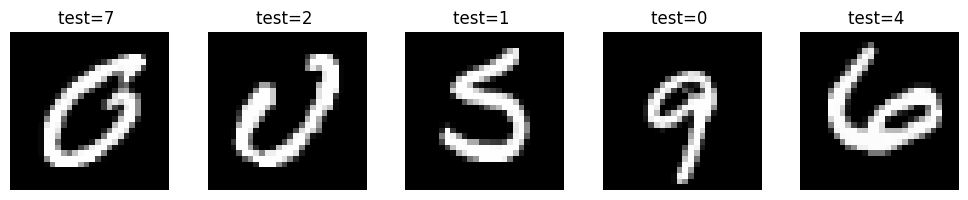

In [7]:
# visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

#  select N samples from x_test by using np.random.choice
idx = np.random.choice(len(x_test), 5)
x_vis = x_test[idx]
y_true = y_test[idx]

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"test={y_test[i-1]} " )
    plt.axis("off")
plt.tight_layout()
plt.show()


2. Build a Fully Connected Neural Network

Define a sequential model using Keras

Flatten the 28x28 input images into a single vector

Add two hidden layers with ReLU activation

Add an output layer with Softmax activation for multi-class
classification

Compile the model using categorical cross-entropy as the loss function and accuracy as the evaluation metric

In [25]:
# Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# compile the model with adam, categorical_crossentropy, and accuracy
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

3. Train the Neural Network

Fit the model to the training data for 10 epochs

Use a validation set to track performance during training

Observe the loss and accuracy trends over the epochs

In [10]:
# train
history = model.fit(
    x_train,
    y_train_oh,
    epochs=10,
    validation_data=(x_test, y_test_oh)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9308 - loss: 0.2321 - val_accuracy: 0.9604 - val_loss: 0.1286
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9701 - loss: 0.0977 - val_accuracy: 0.9685 - val_loss: 0.0968
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9791 - loss: 0.0679 - val_accuracy: 0.9709 - val_loss: 0.0940
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9843 - loss: 0.0500 - val_accuracy: 0.9739 - val_loss: 0.0903
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9866 - loss: 0.0410 - val_accuracy: 0.9739 - val_loss: 0.0931
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9889 - loss: 0.0335 - val_accuracy: 0.9787 - val_loss: 0.0729
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9913 - loss: 0.0270 - val_accuracy: 0.9782 - val_loss: 0.0824
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9919 - loss: 0.0244

In [11]:
# then evaluate
[test_loss, test_acc] = model.evaluate(x_test, y_test_oh)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9795 - loss: 0.0999


4. Evaluate the Model’s Performance

Compute accuracy on the test dataset

Display a confusion matrix for misclassified digits

Identify which digits the model struggles with the most

In [22]:
print("Test accuracy:", test_acc)

from sklearn.metrics import confusion_matrix
import numpy as np

# predictions
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
print()

#which digits the model struggles with the most
errors_per_class = conf_matrix.sum(axis=1) - np.diag(conf_matrix)

for i in range(10):
    print(f"Digit {i}: {errors_per_class[i]} errors")

Test accuracy: 0.9794999957084656
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[ 966    1    2    0    1    0    9    1    0    0]
 [   0 1127    1    1    0    0    2    1    3    0]
 [   1    0 1025    1    0    0    0    2    3    0]
 [   0    0    6  987    0    3    0    6    5    3]
 [   1    2    6    0  958    1    5    2    3    4]
 [   2    0    0    7    0  874    4    0    4    1]
 [   2    2    2    1    2    4  944    0    1    0]
 [   1    2   14    1    1    0    0 1003    2    4]
 [   1    1    7    1    2    1    1    3  955    2]
 [   0    4    2    7   16    7    0    7   10  956]]

Digit 0: 14 errors
Digit 1: 8 errors
Digit 2: 7 errors
Digit 3: 23 errors
Digit 4: 24 errors
Digit 5: 18 errors
Digit 6: 14 errors
Digit 7: 25 errors
Digit 8: 19 errors
Digit 9: 53 errors


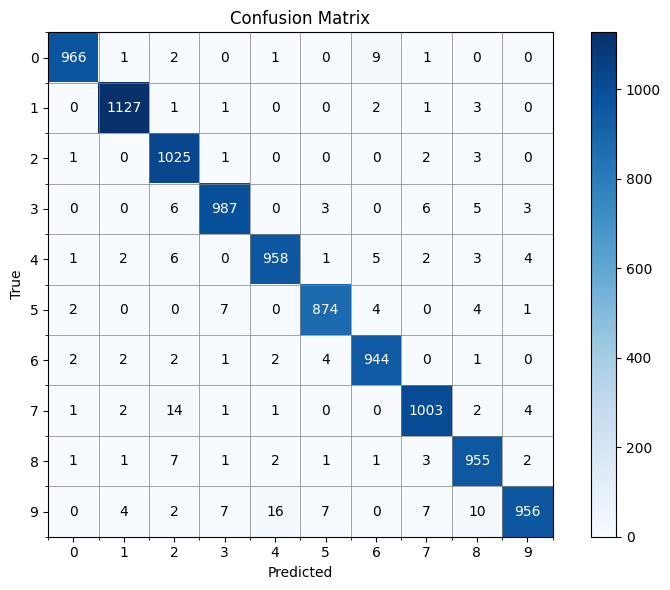

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues', vmin=0, vmax=conf_matrix.max())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")


# Axis labels
ticks = np.arange(10)
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)

# Digits in cells
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        value = conf_matrix[i, j]
        color = "white" if value > conf_matrix.max() / 2 else "black"
        plt.text(j, i, str(value),
                 ha="center", va="center",
                 color=color)

# Grid
plt.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
plt.gca().set_xticks(np.arange(-.5, 10, 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, 10, 1), minor=True)

plt.colorbar()
plt.tight_layout()
plt.show()